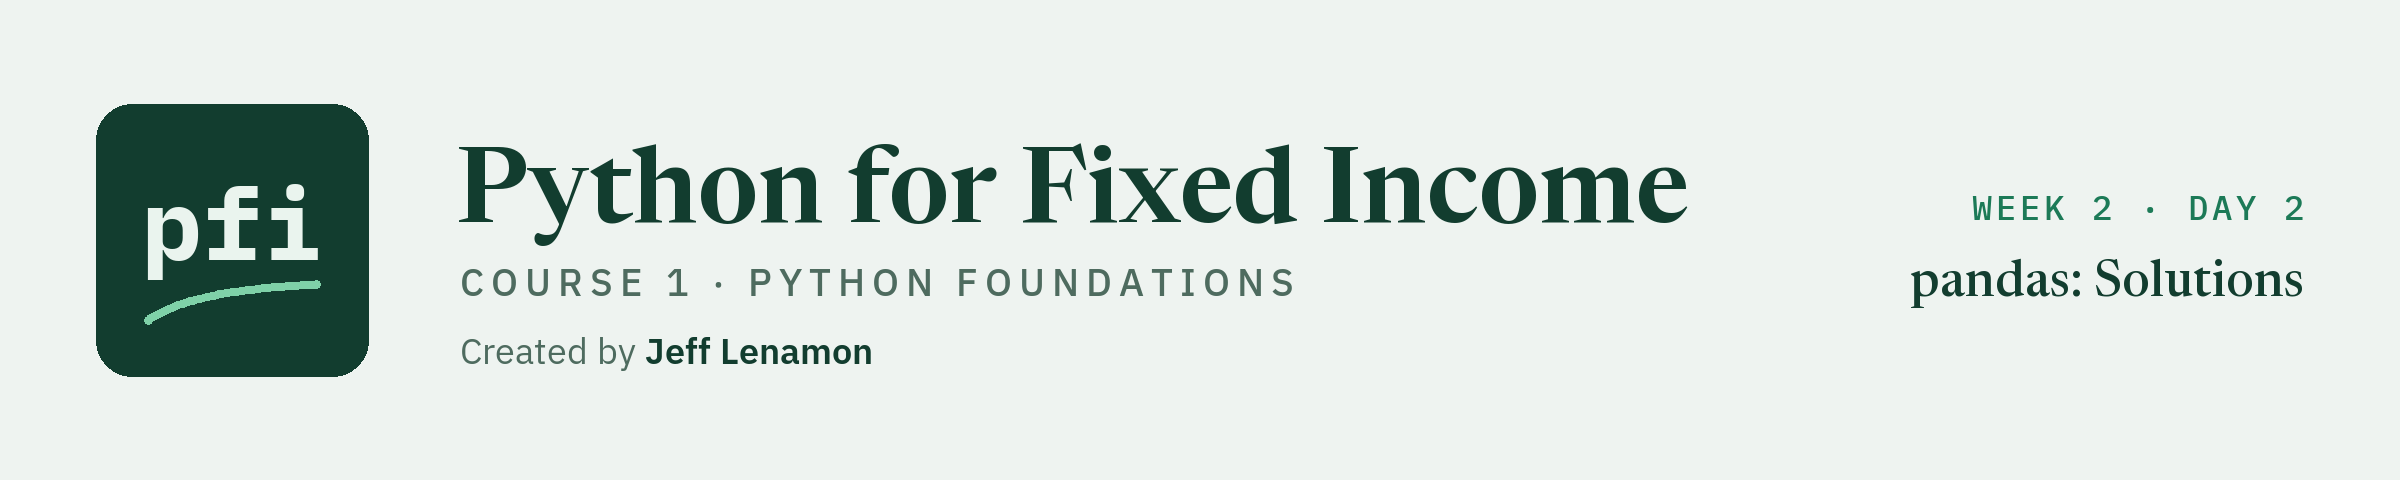

# pandas: Series and DataFrames - Solutions

Week 2. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day2/07_pandas_series_and_dataframes_solutions.ipynb)

## Exercises

The exercises use the same 200-bond holdings file, with questions the lesson did not ask. The issuers are invented.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads a fresh copy of the holdings as it is in the file, and defines `check`, a small function that marks your answers. It allows for tiny rounding differences in numbers with a decimal point.

In [1]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# a fresh copy of the holdings. In Colab it is read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    data_path = '../../../data/holdings.csv'
else:
    data_path = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/holdings.csv'

holdings = pd.read_csv(data_path)
print(holdings.shape)

(200, 19)


### Exercise 1

Q. How many bonds does the desk hold in the Materials sector, and how much face do they add up to? Store the answers in **ex1_count** and **ex1_face**.

In [2]:
# True where the sector is Materials
is_materials = holdings['sector'] == 'Materials'

# the sum of a mask is a count
ex1_count = is_materials.sum()
# the face held in the rows that pass, added up
ex1_face = holdings.loc[is_materials, 'par_held'].sum()

print('Materials bonds:', ex1_count)
print('Materials face held:', ex1_face)

Materials bonds: 26
Materials face held: 70500000


* 26 bonds, holding 70,500,000 of face. The count matches the Materials line of `holdings['sector'].value_counts()`.

In [3]:
check('Exercise 1 count', ex1_count, 26)
check('Exercise 1 face', ex1_face, 70500000)

Exercise 1 count: correct
Exercise 1 face: correct


### Exercise 2

Q. How many bonds are rated BBB+ and have a duration above 7? What is the average OAS of those bonds, rounded to two decimal places? Store the answers in **ex2_count** and **ex2_avg_oas**.

In [4]:
# both conditions must hold, so combine them with &
long_bbb_plus = (holdings['rating'] == 'BBB+') & (holdings['duration'] > 7)

ex2_count = long_bbb_plus.sum()
# the OAS of the rows that pass, averaged
ex2_avg_oas = round(holdings.loc[long_bbb_plus, 'oas'].mean(), 2)

print('BBB+ bonds with a duration above 7:', ex2_count)
print('Their average OAS:', ex2_avg_oas)

BBB+ bonds with a duration above 7: 12
Their average OAS: 114.08


* 12 bonds, with an average OAS of 114.08 basis points. There are 21 BBB+ bonds in all, so the duration test removes 9 of them.

In [5]:
check('Exercise 2 count', ex2_count, 12)
check('Exercise 2 average OAS', ex2_avg_oas, 114.08)

Exercise 2 count: correct
Exercise 2 average OAS: correct


### Exercise 3

Q. Use `isin()` to keep the bonds in the Health Care and Technology sectors, and count them. Among those bonds, find the three with the largest DTS and list their CUSIPs, largest first. Store the answers in **ex3_count** and, as a list, in **ex3_cusips**.

In [6]:
# keep the rows whose sector is one of the two
two_sectors = holdings[holdings['sector'].isin(['Health Care', 'Technology'])]
ex3_count = two_sectors.shape[0]
print('Health Care and Technology bonds:', ex3_count)

# the three rows with the largest DTS, largest first
top_three = two_sectors.nlargest(3, 'dts')
# tolist() turns the cusip column into a plain list
ex3_cusips = top_three['cusip'].tolist()
print('Largest DTS:', ex3_cusips)

top_three[['cusip', 'ticker', 'sector', 'oas', 'spread_duration', 'dts']]

Health Care and Technology bonds: 32
Largest DTS: ['99069RAD2', '99014OAC7', '99016QAE6']


,cusip,ticker,sector,oas,spread_duration,dts
66,99069RAD2,FESR,Technology,614,7.252,4452.7
55,99014OAC7,ELVN,Health Care,346,7.214,2496.0
31,99016QAE6,CORY,Technology,225,11.088,2494.8


* 32 bonds: 20 in Health Care and 12 in Technology.
* The three largest DTS figures are 4,452.7 for a FESR bond, 2,496.0 for ELVN, and 2,494.8 for CORY. The second and third are 1.2 apart, so the order rests on a small difference.

In [7]:
check('Exercise 3 count', ex3_count, 32)
check('Exercise 3 CUSIPs', ex3_cusips, ['99069RAD2', '99014OAC7', '99016QAE6'])

Exercise 3 count: correct
Exercise 3 CUSIPs: correct


### Exercise 4

The desk asks for two figures that are not in the file.

Q. Add a column named `current_yield`: the coupon divided by the price, in percent. Then make a table indexed by CUSIP and use `loc` to look up the current yield of the bond with CUSIP 99071TAG7, rounded to two decimal places. Store it in **ex4_current_yield**.

Q. What percent of the portfolio's market value is in the Utilities sector, rounded to two decimal places? Store it in **ex4_utilities_weight**.

In [8]:
# a new column from two existing ones
holdings['current_yield'] = holdings['coupon'] / holdings['price'] * 100

# the CUSIP as the row label, then a lookup by label and column name
by_cusip = holdings.set_index('cusip')
ex4_current_yield = round(by_cusip.loc['99071TAG7', 'current_yield'], 2)
print('Current yield of 99071TAG7:', ex4_current_yield)

# market value of the Utilities rows over the market value of every row, in percent
utilities_value = holdings.loc[holdings['sector'] == 'Utilities', 'market_value'].sum()
ex4_utilities_weight = round(utilities_value / holdings['market_value'].sum() * 100, 2)
print('Utilities weight:', ex4_utilities_weight)

Current yield of 99071TAG7: 4.1
Utilities weight: 5.91


* The bond is a CORL 4% priced at 97.612, so its current yield is 4 divided by 97.612, or 4.1 percent to two decimal places.
* Utilities is 5.91 percent of the portfolio's market value. It has 12 of the 200 bonds, which is 6 percent by count.

In [9]:
check('Exercise 4 current yield', ex4_current_yield, 4.1)
check('Exercise 4 Utilities weight', ex4_utilities_weight, 5.91)

Exercise 4 current yield: correct
Exercise 4 Utilities weight: correct


### Exercise 5: AI check

You ask an AI assistant for the number of bonds that are rated BBB+ and have a duration above 7, and for the average OAS of those bonds. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Read the code before you run it. What numbers do you expect? You worked both out yourself in Exercise 2. Then run the code. Does it agree with you?

* The answers from Exercise 2 are 12 bonds and an average OAS of 114.08. The original code printed 88 bonds and 148.12, with no error.
* The bug was the `|` between the two conditions. That keeps a bond when either condition is True: every BBB+ bond of any duration, plus every bond of any rating with a duration above 7. The question said 'and', which is `&`.
* Both wrong figures looked plausible. 88 is a believable count for a 200-bond portfolio and 148.12 is a believable spread. The check that caught it was a number worked out independently. A quick second check: the file has only 21 BBB+ bonds, so no filter that requires BBB+ can return 88.

In [10]:
# both conditions must hold, so the symbol between them is &
ai_filter = (holdings['rating'] == 'BBB+') & (holdings['duration'] > 7)

ex5_count = ai_filter.sum()
ex5_avg_oas = round(holdings.loc[ai_filter, 'oas'].mean(), 2)

print('Bonds rated BBB+ with a duration above 7:', ex5_count)
print('Their average OAS:', ex5_avg_oas)

Bonds rated BBB+ with a duration above 7: 12
Their average OAS: 114.08


In [11]:
check('Exercise 5 count', ex5_count, 12)
check('Exercise 5 average OAS', ex5_avg_oas, 114.08)

Exercise 5 count: correct
Exercise 5 average OAS: correct
